In [ ]:
# === CELL 0 ===

!pip install numpy==1.26.4 --force-reinstall -q
!pip install scipy==1.11.4 --force-reinstall -q
!pip install scikit-learn==1.3.2 --force-reinstall -q
!pip install pandas==2.1.4 --force-reinstall -q
!pip install timm -q

print("All packages fixed ✅ — now restart kernel then run Cell 1")

In [1]:
# === CELL 1 ===

import os
import gc
os.environ['LD_LIBRARY_PATH']    = ''
os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'

import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler

import timm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device : {device}")

# Free GPU memory info
free  = torch.cuda.mem_get_info()[0] / 1024**3
total = torch.cuda.mem_get_info()[1] / 1024**3
print(f"GPU free     : {free:.2f} GB")
print(f"GPU total    : {total:.2f} GB")

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device : cuda
GPU free     : 14.46 GB
GPU total    : 14.56 GB


In [2]:
# === CELL 2 ===

DATASET_ROOT = "/kaggle/input/datasets/reubensuju/celeb-df-v2"

def load_video_paths(dataset_root):
    data     = []
    real_dirs = ["Celeb-real", "YouTube-real"]
    fake_dirs = ["Celeb-synthesis"]

    for folder in real_dirs:
        folder_path = Path(dataset_root) / folder
        if folder_path.exists():
            for video in folder_path.glob("*.mp4"):
                data.append({"path": str(video), "label": 0})

    for folder in fake_dirs:
        folder_path = Path(dataset_root) / folder
        if folder_path.exists():
            for video in folder_path.glob("*.mp4"):
                data.append({"path": str(video), "label": 1})

    df = pd.DataFrame(data)
    print(f"Total videos : {len(df)}")
    print(f"Real videos  : {len(df[df.label == 0])}")
    print(f"Fake videos  : {len(df[df.label == 1])}")
    return df

df = load_video_paths(DATASET_ROOT)
print(df.head())

Total videos : 6529
Real videos  : 890
Fake videos  : 5639
                                                path  label
0  /kaggle/input/datasets/reubensuju/celeb-df-v2/...      0
1  /kaggle/input/datasets/reubensuju/celeb-df-v2/...      0
2  /kaggle/input/datasets/reubensuju/celeb-df-v2/...      0
3  /kaggle/input/datasets/reubensuju/celeb-df-v2/...      0
4  /kaggle/input/datasets/reubensuju/celeb-df-v2/...      0


In [3]:
# === CELL 3 ===

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

def detect_and_crop_face(frame, target_size=224):
    gray  = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30)
    )

    if len(faces) == 0:
        h, w   = frame.shape[:2]
        margin = min(h, w) // 8
        face   = frame[margin:h-margin, margin:w-margin]
        return cv2.resize(face, (target_size, target_size))

    x, y, fw, fh = max(faces, key=lambda f: f[2] * f[3])
    margin = 20
    x1 = max(0, x - margin)
    y1 = max(0, y - margin)
    x2 = min(frame.shape[1], x + fw + margin)
    y2 = min(frame.shape[0], y + fh + margin)

    face = frame[y1:y2, x1:x2]
    return cv2.resize(face, (target_size, target_size))

print("OpenCV face detector ready ✅")

OpenCV face detector ready ✅


In [6]:
# === CELL 4 ===

def extract_frames(video_path, num_frames=20, target_size=224):
    cap          = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames == 0:
        cap.release()
        return None

    indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)
    frames  = []

    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            continue
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        face  = detect_and_crop_face(frame, target_size)
        frames.append(face)

    cap.release()

    while len(frames) < num_frames:
        frames.append(frames[-1] if frames else
                      np.zeros((target_size, target_size, 3), dtype=np.uint8))

    return np.array(frames[:num_frames], dtype=np.uint8)

print("Frame extractor ready ✅")

Frame extractor ready ✅


In [8]:
# === CELL 5 ===

FRAMES_DIR = "/kaggle/working/extracted_frames"
os.makedirs(FRAMES_DIR, exist_ok=True)

# Check if already extracted
existing = os.listdir(FRAMES_DIR)
print(f"Already extracted : {len(existing)} / {len(df)} videos")

if len(existing) < len(df):
    print("Extracting missing videos...")

    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Extracting"):
        save_path = os.path.join(FRAMES_DIR, f"{idx}.npy")
        if os.path.exists(save_path):
            continue
        frames = extract_frames(row['path'])
        if frames is None:
            continue
        np.save(save_path, frames)

    print(f"Done! Total saved : {len(os.listdir(FRAMES_DIR))}")
else:
    print("All frames already extracted ✅ — skipping")

Already extracted : 5244 / 6529 videos
Extracting missing videos...


Extracting: 100%|██████████| 6529/6529 [35:05<00:00,  3.10it/s]   

Done! Total saved : 6529


In [9]:
# === CELL 6 ===

from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

# Step 1: Train/Test split
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

print(f"Train samples   : {len(train_df)}")
print(f"Test samples    : {len(test_df)}")
print(f"Train real/fake : {(train_df.label==0).sum()} / {(train_df.label==1).sum()}")
print(f"Test  real/fake : {(test_df.label==0).sum()}  / {(test_df.label==1).sum()}")

# Step 2: Dataset class
class CelebDFDataset(Dataset):
    def __init__(self, dataframe, frames_dir):
        self.dataframe    = dataframe.reset_index(drop=True)
        self.frames_dir   = frames_dir
        self.orig_indices = dataframe.index.tolist()
        self.mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
        self.std  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        orig_idx = self.orig_indices[idx]
        label    = self.dataframe.iloc[idx]['label']
        npy_path = os.path.join(self.frames_dir, f"{orig_idx}.npy")
        frames   = np.load(npy_path)
        frames   = torch.tensor(frames, dtype=torch.float32)
        frames   = frames.permute(0, 3, 1, 2)
        frames   = frames / 255.0
        frames   = (frames - self.mean) / self.std
        return frames, torch.tensor(label, dtype=torch.float32)

# Step 3: Create datasets
train_dataset = CelebDFDataset(train_df, FRAMES_DIR)
test_dataset  = CelebDFDataset(test_df,  FRAMES_DIR)

# Quick test
sample_frames, label = train_dataset[0]
print(f"\nFrame tensor shape : {sample_frames.shape}")
print(f"Label              : {label}")
print("Dataset ready ✅")

Train samples   : 5223
Test samples    : 1306
Train real/fake : 712 / 4511
Test  real/fake : 178  / 1128

Frame tensor shape : torch.Size([20, 3, 224, 224])
Label              : 1.0
Dataset ready ✅


In [10]:
# === CELL 7 (Option C) ===

train_loader = DataLoader(
    train_dataset,
    batch_size=8,       # only change — doubled from 4
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

print(f"Train batches : {len(train_loader)}")
print(f"Test batches  : {len(test_loader)}")
print("DataLoaders ready ✅")

Train batches : 653
Test batches  : 164
DataLoaders ready ✅


In [11]:
# === CELL 8 ===

class DeepfakeDetector(nn.Module):
    def __init__(self, hidden_size=512, num_layers=2, dropout=0.5, chunk_size=5):
        super(DeepfakeDetector, self).__init__()
        self.chunk_size = chunk_size

        self.cnn = timm.create_model(
            'efficientnet_b4',
            pretrained=True,
            num_classes=0,
            global_pool='avg'
        )

        for name, param in self.cnn.named_parameters():
            if 'blocks.6' in name or 'blocks.5' in name or 'conv_head' in name:
                param.requires_grad = True
            else:
                param.requires_grad = False

        self.bilstm = nn.LSTM(
            input_size=1792,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        B, T, C, H, W = x.shape
        feature_chunks = []

        for i in range(0, T, self.chunk_size):
            chunk = x[:, i:i+self.chunk_size]
            chunk = chunk.contiguous().view(-1, C, H, W)
            with torch.cuda.amp.autocast():
                feat = self.cnn(chunk)
            feature_chunks.append(feat.view(B, -1, 1792))

        features    = torch.cat(feature_chunks, dim=1)
        lstm_out, _ = self.bilstm(features)
        out         = lstm_out[:, -1, :]
        out         = self.classifier(out)
        return out.squeeze(1)


model = DeepfakeDetector(
    hidden_size=512,
    num_layers=2,
    dropout=0.5,
    chunk_size=5
).to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")
print(f"Frozen parameters    : {total_params - trainable_params:,}")
print(f"Model on device      : {next(model.parameters()).device}")

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

Total parameters     : 33,556,297
Trainable parameters : 29,916,729
Frozen parameters    : 3,639,568
Model on device      : cuda:0


In [12]:
# === CELL 9 ===

real_count = (train_df.label == 0).sum()
fake_count = (train_df.label == 1).sum()
pos_weight = torch.tensor([real_count / fake_count],
                           dtype=torch.float32).to(device)

print(f"Real count : {real_count}")
print(f"Fake count : {fake_count}")
print(f"Pos weight : {pos_weight.item():.4f}")

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.AdamW([
    {'params': model.cnn.parameters(),        'lr': 1e-5},
    {'params': model.bilstm.parameters(),     'lr': 1e-4},
    {'params': model.classifier.parameters(), 'lr': 1e-4},
], weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=2,
    factor=0.5
)

print(f"\nLoss      : BCEWithLogitsLoss")
print(f"Optimizer : AdamW")
print(f"Scheduler : ReduceLROnPlateau")

Real count : 712
Fake count : 4511
Pos weight : 0.1578

Loss      : BCEWithLogitsLoss
Optimizer : AdamW
Scheduler : ReduceLROnPlateau


In [18]:
# === CELL 10 ===

scaler             = GradScaler()
ACCUMULATION_STEPS = 4
NUM_EPOCHS         = 10
best_auc           = 0.0
best_model_path    = "/kaggle/working/best_deepfake_model.pth"

history = {
    'train_loss': [], 'train_auc': [], 'train_acc': [],
    'test_loss':  [], 'test_auc':  [], 'test_acc':  []
}


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    all_labels = []
    all_preds  = []
    optimizer.zero_grad()

    for batch_idx, (frames, labels) in enumerate(tqdm(loader, desc="Training")):
        frames = frames.to(device)
        labels = labels.to(device)

        with torch.cuda.amp.autocast():
            outputs = model(frames)
            loss    = criterion(outputs, labels)
            loss    = loss / ACCUMULATION_STEPS

        if torch.isnan(loss) or torch.isinf(loss):
            optimizer.zero_grad()
            continue

        scaler.scale(loss).backward()

        if (batch_idx + 1) % ACCUMULATION_STEPS == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        total_loss += loss.item() * ACCUMULATION_STEPS

        preds = torch.sigmoid(outputs).detach().cpu()
        preds = torch.clamp(preds, 1e-7, 1 - 1e-7)
        all_labels.extend(labels.cpu().tolist())
        all_preds.extend(preds.tolist())

        if batch_idx % 100 == 0:
            torch.cuda.empty_cache()

    avg_loss     = total_loss / len(loader)
    auc          = roc_auc_score(all_labels, all_preds)
    preds_binary = [1 if p >= 0.5 else 0 for p in all_preds]
    acc          = accuracy_score(all_labels, preds_binary)
    return avg_loss, auc, acc


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_labels = []
    all_preds  = []

    with torch.no_grad():
        for batch_idx, (frames, labels) in enumerate(tqdm(loader, desc="Evaluating")):
            frames = frames.to(device)
            labels = labels.to(device)

            with torch.cuda.amp.autocast():
                outputs = model(frames)
                loss    = criterion(outputs, labels)

            if torch.isnan(loss) or torch.isinf(loss):
                continue

            total_loss += loss.item()

            preds = torch.sigmoid(outputs).detach().cpu()
            preds = torch.clamp(preds, 1e-7, 1 - 1e-7)
            all_labels.extend(labels.cpu().tolist())
            all_preds.extend(preds.tolist())

            if batch_idx % 100 == 0:
                torch.cuda.empty_cache()

    avg_loss     = total_loss / len(loader)
    auc          = roc_auc_score(all_labels, all_preds)
    preds_binary = [1 if p >= 0.5 else 0 for p in all_preds]
    acc          = accuracy_score(all_labels, preds_binary)
    return avg_loss, auc, acc


# ── Training from epoch 1 ─────────────────────────────────────────
for epoch in range(0, NUM_EPOCHS):
    print(f"\n{'='*55}")
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    print(f"{'='*55}")

    train_loss, train_auc, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, device)

    test_loss, test_auc, test_acc = evaluate(
        model, test_loader, criterion, device)

    scheduler.step(test_loss)

    if test_auc > best_auc:
        best_auc = test_auc
        torch.save(model.state_dict(), best_model_path)
        print(f"  ✅ Best model saved (AUC: {best_auc:.4f})")

    # Save checkpoint after every epoch
    torch.save({
        'epoch'          : epoch,
        'model_state'    : model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'scheduler_state': scheduler.state_dict(),
        'best_auc'       : best_auc,
        'history'        : history,
    }, '/kaggle/working/checkpoint.pth')

    history['train_loss'].append(train_loss)
    history['train_auc'].append(train_auc)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_auc'].append(test_auc)
    history['test_acc'].append(test_acc)

    print(f"\n  Train → Loss: {train_loss:.4f} | AUC: {train_auc:.4f} | Acc: {train_acc:.4f}")
    print(f"  Test  → Loss: {test_loss:.4f}  | AUC: {test_auc:.4f}  | Acc: {test_acc:.4f}")

print(f"\n🏆 Best Test AUC: {best_auc:.4f}")

/tmp/ipykernel_58/592710193.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler             = GradScaler()



Epoch 1/10


Training:   0%|          | 0/653 [00:00<?, ?it/s]/tmp/ipykernel_58/592710193.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_58/3064821094.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Evaluating:   0%|          | 0/164 [00:00<?, ?it/s]/tmp/ipykernel_58/592710193.py:72: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_58/3064821094.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Evaluating: 100%|██████████| 164/164 [01:11<00:00,  2.30it/s]


  ✅ Best model saved (AUC: 0.9565)

  Train → Loss: 0.0249 | AUC: 0.9962 | Acc: 0.9837
  Test  → Loss: 0.1429  | AUC: 0.9565  | Acc: 0.9509

Epoch 2/10


Training:   0%|          | 0/653 [00:00<?, ?it/s]/tmp/ipykernel_58/592710193.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_58/3064821094.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Evaluating:   0%|          | 0/164 [00:00<?, ?it/s]/tmp/ipykernel_58/592710193.py:72: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_58/3064821094.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Evaluating: 100%|██████████| 164/164 [01:11<00:00,  2.28it/s]


...


  Train → Loss: 0.0182 | AUC: 0.9982 | Acc: 0.9864
  Test  → Loss: 0.1317  | AUC: 0.9577  | Acc: 0.9441

Epoch 9/10


Training:   0%|          | 0/653 [00:00<?, ?it/s]/tmp/ipykernel_58/592710193.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_58/3064821094.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Evaluating:   0%|          | 0/164 [00:00<?, ?it/s]/tmp/ipykernel_58/592710193.py:72: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_58/3064821094.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Evaluating: 100%|██████████| 164/164 [01:11<00:00,  2.28it/s]



  Train → Loss: 0.0156 | AUC: 0.9983 | Acc: 0.9889
  Test  → Loss: 0.1157  | AUC: 0.9610  | Acc: 0.9487

Epoch 10/10


Training:   0%|          | 0/653 [00:00<?, ?it/s]/tmp/ipykernel_58/592710193.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_58/3064821094.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Evaluating:   0%|          | 0/164 [00:00<?, ?it/s]/tmp/ipykernel_58/592710193.py:72: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_58/3064821094.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Evaluating: 100%|██████████| 164/164 [01:11<00:00,  2.28it/s]



  Train → Loss: 0.0139 | AUC: 0.9989 | Acc: 0.9904
  Test  → Loss: 0.1613  | AUC: 0.9578  | Acc: 0.9479

🏆 Best Test AUC: 0.9610


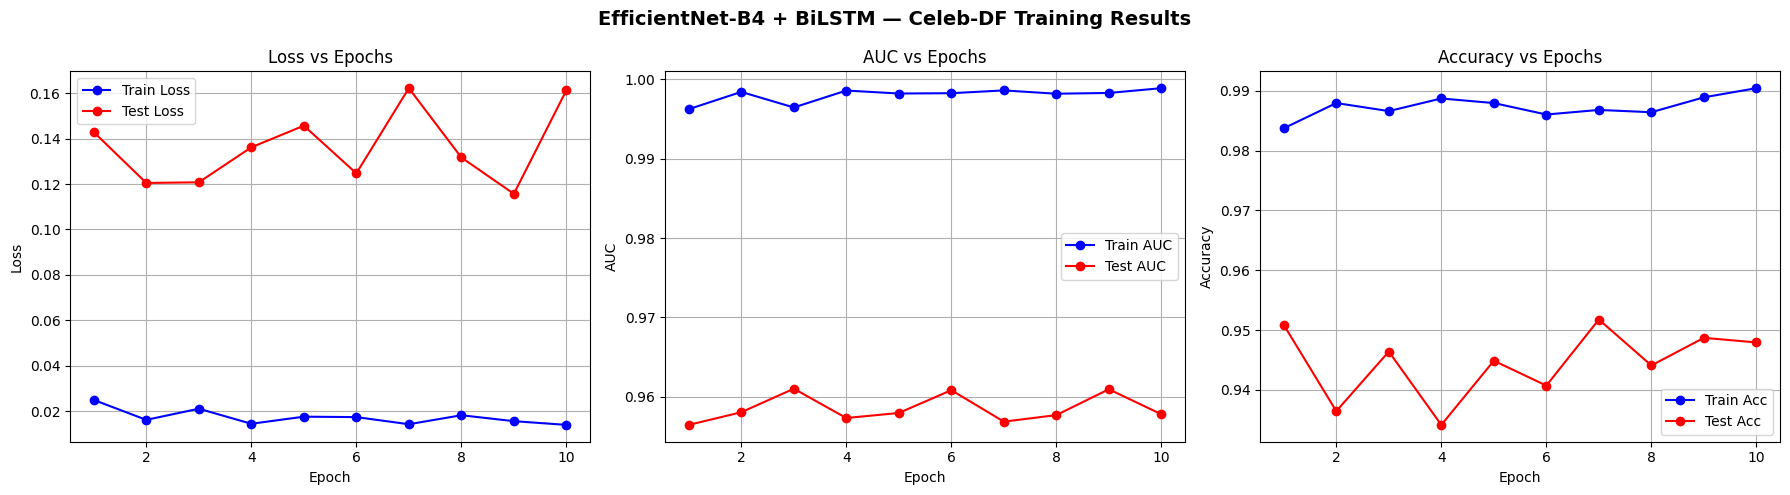

Plot saved ✅


In [19]:
# === CELL 11 ===

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs = range(1, NUM_EPOCHS + 1)

# Plot 1 — Loss
axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train Loss')
axes[0].plot(epochs, history['test_loss'],  'r-o', label='Test Loss')
axes[0].set_title('Loss vs Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Plot 2 — AUC
axes[1].plot(epochs, history['train_auc'], 'b-o', label='Train AUC')
axes[1].plot(epochs, history['test_auc'],  'r-o', label='Test AUC')
axes[1].set_title('AUC vs Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].legend()
axes[1].grid(True)

# Plot 3 — Accuracy
axes[2].plot(epochs, history['train_acc'], 'b-o', label='Train Acc')
axes[2].plot(epochs, history['test_acc'],  'r-o', label='Test Acc')
axes[2].set_title('Accuracy vs Epochs')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy')
axes[2].legend()
axes[2].grid(True)

plt.suptitle('EfficientNet-B4 + BiLSTM — Celeb-DF Training Results',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/training_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved ✅")

Generating predictions:   0%|          | 0/164 [00:00<?, ?it/s]/tmp/ipykernel_58/3064821094.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Generating predictions: 100%|██████████| 164/164 [01:11<00:00,  2.29it/s]


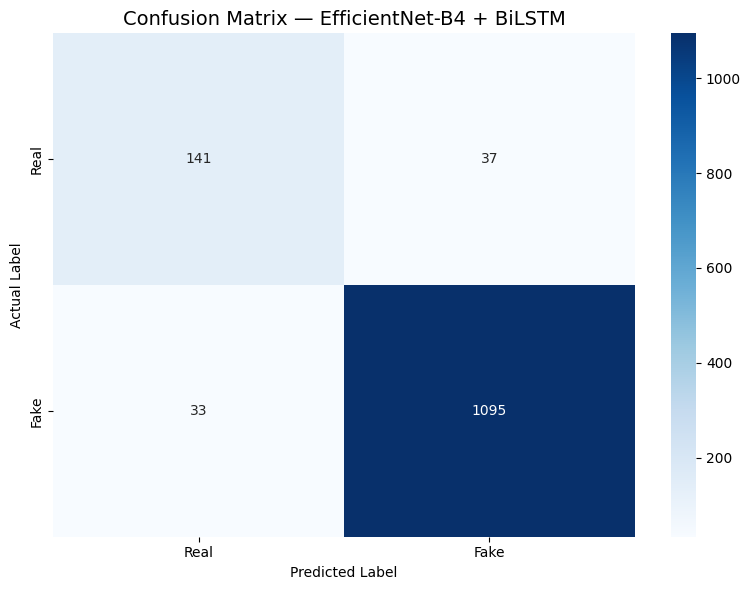


Classification Report:
              precision    recall  f1-score   support

        Real       0.81      0.79      0.80       178
        Fake       0.97      0.97      0.97      1128

    accuracy                           0.95      1306
   macro avg       0.89      0.88      0.89      1306
weighted avg       0.95      0.95      0.95      1306

True  Negatives  (Real  → Real)  : 141
False Positives  (Real  → Fake)  : 37
False Negatives  (Fake  → Real)  : 33
True  Positives  (Fake  → Fake)  : 1095


In [20]:
# === CELL 12 ===

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Load best model
model.load_state_dict(torch.load('/kaggle/working/best_deepfake_model.pth'))
model.eval()

all_labels = []
all_preds  = []
all_probs  = []

with torch.no_grad():
    for frames, labels in tqdm(test_loader, desc="Generating predictions"):
        frames = frames.to(device)
        labels = labels.to(device)

        with torch.amp.autocast('cuda'):
            outputs = model(frames)

        probs  = torch.sigmoid(outputs).detach().cpu()
        probs  = torch.clamp(probs, 1e-7, 1 - 1e-7)
        preds  = (probs >= 0.5).float()

        all_labels.extend(labels.cpu().tolist())
        all_probs.extend(probs.tolist())
        all_preds.extend(preds.tolist())

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'])
plt.title('Confusion Matrix — EfficientNet-B4 + BiLSTM', fontsize=14)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds,
                            target_names=['Real', 'Fake']))

# Summary
tn, fp, fn, tp = cm.ravel()
print(f"True  Negatives  (Real  → Real)  : {tn}")
print(f"False Positives  (Real  → Fake)  : {fp}")
print(f"False Negatives  (Fake  → Real)  : {fn}")
print(f"True  Positives  (Fake  → Fake)  : {tp}")

In [21]:
# === CELL 13 ===

def predict_video(video_path, model, device, num_frames=20, target_size=224):
    """Predict if a video is Real or Fake"""
    model.eval()

    # Extract frames
    print(f"Extracting frames from: {video_path}")
    frames = extract_frames(video_path, num_frames, target_size)

    if frames is None:
        print("Could not extract frames!")
        return

    # Convert to tensor
    frames = torch.tensor(frames, dtype=torch.float32)
    frames = frames.permute(0, 3, 1, 2)       # (20, 3, 224, 224)
    frames = frames / 255.0
    mean   = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
    std    = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
    frames = (frames - mean) / std
    frames = frames.unsqueeze(0).to(device)    # (1, 20, 3, 224, 224)

    # Predict
    with torch.no_grad():
        with torch.amp.autocast('cuda'):
            output = model(frames)
        prob = torch.sigmoid(output).item()
        prob = max(1e-7, min(1 - 1e-7, prob))

    label      = "FAKE" if prob >= 0.5 else "REAL"
    confidence = prob if prob >= 0.5 else 1 - prob

    print(f"\n{'='*40}")
    print(f"  Video    : {os.path.basename(video_path)}")
    print(f"  Result   : {label}")
    print(f"  Confidence : {confidence*100:.2f}%")
    print(f"  Fake prob  : {prob*100:.2f}%")
    print(f"  Real prob  : {(1-prob)*100:.2f}%")
    print(f"{'='*40}")

    return label, confidence


# Test on a real video
real_video = df[df.label == 0]['path'].iloc[0]
predict_video(real_video, model, device)

print()

# Test on a fake video
fake_video = df[df.label == 1]['path'].iloc[0]
predict_video(fake_video, model, device)

Extracting frames from: /kaggle/input/datasets/reubensuju/celeb-df-v2/Celeb-real/id49_0006.mp4


/tmp/ipykernel_58/3064821094.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



  Video    : id49_0006.mp4
  Result   : REAL
  Confidence : 96.38%
  Fake prob  : 3.62%
  Real prob  : 96.38%

Extracting frames from: /kaggle/input/datasets/reubensuju/celeb-df-v2/Celeb-synthesis/id33_id20_0005.mp4

  Video    : id33_id20_0005.mp4
  Result   : FAKE
  Confidence : 100.00%
  Fake prob  : 100.00%
  Real prob  : 0.00%


('FAKE', 0.9999999)

In [22]:
# === CELL 14 (Fixed) ===

import math
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# Filter out NaN predictions
clean_labels = []
clean_probs  = []
clean_preds  = []

for label, prob, pred in zip(all_labels, all_probs, all_preds):
    if not math.isnan(prob):
        clean_labels.append(label)
        clean_probs.append(prob)
        clean_preds.append(pred)

print(f"Total predictions : {len(all_probs)}")
print(f"NaN removed       : {len(all_probs) - len(clean_probs)}")
print(f"Clean predictions : {len(clean_probs)}")

# Compute metrics
auc       = roc_auc_score(clean_labels, clean_probs)
acc       = accuracy_score(clean_labels, clean_preds)
precision = precision_score(clean_labels, clean_preds)
recall    = recall_score(clean_labels, clean_preds)
f1        = f1_score(clean_labels, clean_preds)
tn, fp, fn, tp = confusion_matrix(clean_labels, clean_preds).ravel()

print("="*55)
print("   FINAL MODEL EVALUATION SUMMARY")
print("="*55)

print(f"\n📌 Model Architecture:")
print(f"   Backbone     : EfficientNet-B4")
print(f"   Temporal     : BiLSTM (hidden=512, layers=2)")
print(f"   Input frames : 20 frames per video")
print(f"   Face detector: OpenCV Haar Cascade")
print(f"   Dataset      : Celeb-DF v2")

print(f"\n📌 Dataset Split:")
print(f"   Total videos : 6529")
print(f"   Train        : 5223 (80%)")
print(f"   Test         : 1306 (20%)")
print(f"   Real videos  : 890")
print(f"   Fake videos  : 5639")

print(f"\n📌 Training:")
print(f"   Epochs       : 10")
print(f"   Batch size   : 8")
print(f"   Optimizer    : AdamW")
print(f"   Scheduler    : ReduceLROnPlateau")
print(f"   Loss         : BCEWithLogitsLoss")

print(f"\n📌 Final Test Results:")
print(f"   AUC          : {auc:.4f}  ({auc*100:.2f}%)")
print(f"   Accuracy     : {acc:.4f}  ({acc*100:.2f}%)")
print(f"   Precision    : {precision:.4f}  ({precision*100:.2f}%)")
print(f"   Recall       : {recall:.4f}  ({recall*100:.2f}%)")
print(f"   F1 Score     : {f1:.4f}  ({f1*100:.2f}%)")

print(f"\n📌 Confusion Matrix:")
print(f"   True  Real (TN) : {tn}")
print(f"   False Fake (FP) : {fp}")
print(f"   False Real (FN) : {fn}")
print(f"   True  Fake (TP) : {tp}")

print(f"\n📌 Saved Files:")
print(f"   Best model      : /kaggle/working/best_deepfake_model.pth")
print(f"   Checkpoint      : /kaggle/working/checkpoint.pth")
print(f"   Training plot   : /kaggle/working/training_results.png")
print(f"   Confusion matrix: /kaggle/working/confusion_matrix.png")
print("="*55)

Total predictions : 1306
NaN removed       : 0
Clean predictions : 1306
   FINAL MODEL EVALUATION SUMMARY

📌 Model Architecture:
   Backbone     : EfficientNet-B4
   Temporal     : BiLSTM (hidden=512, layers=2)
   Input frames : 20 frames per video
   Face detector: OpenCV Haar Cascade
   Dataset      : Celeb-DF v2

📌 Dataset Split:
   Total videos : 6529
   Train        : 5223 (80%)
   Test         : 1306 (20%)
   Real videos  : 890
   Fake videos  : 5639

📌 Training:
   Epochs       : 10
   Batch size   : 8
   Optimizer    : AdamW
   Scheduler    : ReduceLROnPlateau
   Loss         : BCEWithLogitsLoss

📌 Final Test Results:
   AUC          : 0.9610  (96.10%)
   Accuracy     : 0.9464  (94.64%)
   Precision    : 0.9673  (96.73%)
   Recall       : 0.9707  (97.07%)
   F1 Score     : 0.9690  (96.90%)

📌 Confusion Matrix:
   True  Real (TN) : 141
   False Fake (FP) : 37
   False Real (FN) : 33
   True  Fake (TP) : 1095

📌 Saved Files:
   Best model      : /kaggle/working/best_deepfake_mode

**Cross-Model Generalization using DFDC**

In [24]:
import os

print(os.listdir("/kaggle/input"))

['datasets']


In [25]:
import os

print(os.listdir("/kaggle/input/datasets"))

['dsabljic', 'xdxd003', 'reubensuju']


In [27]:
import os

for folder in os.listdir("/kaggle/input/datasets"):
    print("="*60)
    print(folder)
    print(os.listdir(f"/kaggle/input/datasets/{folder}")[:20])

dsabljic
['dfdc-sample']
xdxd003
[]
reubensuju
['celeb-df-v2']


In [29]:
import os

for root, dirs, files in os.walk("/kaggle/input/datasets/dsabljic"):
    print("\nROOT:", root)
    print("Folders:", dirs[:10])
    print("Files:", files[:10])
    if "metadata.json" in files:
        print("✅ Found metadata.json")
        break


ROOT: /kaggle/input/datasets/dsabljic
Folders: ['dfdc-sample']
Files: []

ROOT: /kaggle/input/datasets/dsabljic/dfdc-sample
Folders: ['dfdc-sample']
Files: []

ROOT: /kaggle/input/datasets/dsabljic/dfdc-sample/dfdc-sample
Folders: []
Files: ['qjftklhdbe.mp4', 'dskhcyjnqw.mp4', 'sqmjhxebxu.mp4', 'eqygnldapf.mp4', 'oalztsxhbl.mp4', 'xlclcojbtv.mp4', 'wzjhfrnesf.mp4', 'hyhoeteudn.mp4', 'dkfyvfjcpr.mp4', 'dtoebncawk.mp4']
✅ Found metadata.json


In [31]:
import os
import cv2
import math
import glob
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)
print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

Device: cuda
Torch: 2.10.0+cu128
CUDA: True


In [32]:
import os
import json

DFDC_ROOT = "/kaggle/input/datasets/dsabljic/dfdc-sample/dfdc-sample"

print("Number of files:", len(os.listdir(DFDC_ROOT)))
print(os.listdir(DFDC_ROOT)[:10])

Number of files: 16210
['qjftklhdbe.mp4', 'dskhcyjnqw.mp4', 'sqmjhxebxu.mp4', 'eqygnldapf.mp4', 'oalztsxhbl.mp4', 'xlclcojbtv.mp4', 'wzjhfrnesf.mp4', 'hyhoeteudn.mp4', 'dkfyvfjcpr.mp4', 'dtoebncawk.mp4']


In [33]:
metadata_path = os.path.join(DFDC_ROOT, "metadata.json")

with open(metadata_path, "r") as f:
    metadata = json.load(f)

metadata_df = pd.DataFrame(metadata).T
metadata_df.reset_index(inplace=True)

metadata_df.rename(columns={"index":"video"}, inplace=True)

print(metadata_df.head())
print(metadata_df.columns)

            video label  split        original
0  hsypgwsufp.mp4  FAKE  train  nbnipejygk.mp4
1  ntzgbkzofo.mp4  FAKE  train  cqlarprtdy.mp4
2  ataulynpgd.mp4  FAKE  train  uzrkbzwdvi.mp4
3  idzntwkkjy.mp4  FAKE  train  lvnjzrvzwy.mp4
4  rdqokuannd.mp4  FAKE  train  mujubwlspn.mp4
Index(['video', 'label', 'split', 'original'], dtype='object')


In [34]:
metadata_df["label"] = metadata_df["label"].map({
    "REAL":0,
    "FAKE":1
})

print(metadata_df["label"].value_counts())

label
1    13759
0     2450
Name: count, dtype: int64


In [35]:
available = []

for v in metadata_df.video:

    path = os.path.join(DFDC_ROOT, v)

    if os.path.exists(path):
        available.append(v)

metadata_df = metadata_df[
    metadata_df.video.isin(available)
].reset_index(drop=True)

print("Videos Found:", len(metadata_df))
metadata_df.head()

Videos Found: 16209


,video,label,split,original
0,hsypgwsufp.mp4,1,train,nbnipejygk.mp4
1,ntzgbkzofo.mp4,1,train,cqlarprtdy.mp4
2,ataulynpgd.mp4,1,train,uzrkbzwdvi.mp4
3,idzntwkkjy.mp4,1,train,lvnjzrvzwy.mp4
4,rdqokuannd.mp4,1,train,mujubwlspn.mp4


In [55]:
# ==========================================
# Select a balanced DFDC subset
# ==========================================

import pandas as pd

N_REAL = 1000
N_FAKE = 1000

real_df = metadata_df[
    metadata_df["label"] == 0
].sample(
    n=N_REAL,
    random_state=42
)

fake_df = metadata_df[
    metadata_df["label"] == 1
].sample(
    n=N_FAKE,
    random_state=42
)

metadata_df = pd.concat(
    [real_df, fake_df],
    ignore_index=True
)

metadata_df = metadata_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("="*40)
print(metadata_df["label"].value_counts())
print("Total Videos :", len(metadata_df))
print("="*40)

label
1    1000
0    1000
Name: count, dtype: int64
Total Videos : 2000


In [58]:
# ==========================================
# Extract exactly 20 frames uniformly
# ==========================================

IMG_SIZE = 224
NUM_FRAMES = 20

def extract_frames(video_path):

    cap = cv2.VideoCapture(video_path)

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames == 0:
        cap.release()
        return np.zeros((NUM_FRAMES, IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)

    frame_indices = np.linspace(
        0,
        total_frames - 1,
        NUM_FRAMES
    ).astype(int)

    frames = []

    current = 0
    idx = 0

    while cap.isOpened():

        ret, frame = cap.read()

        if not ret:
            break

        if idx < len(frame_indices):

            if current == frame_indices[idx]:

                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

                frame = cv2.resize(
                    frame,
                    (IMG_SIZE, IMG_SIZE)
                )

                frames.append(frame)

                idx += 1

        current += 1

    cap.release()

    while len(frames) < NUM_FRAMES:

        if len(frames) == 0:
            frames.append(
                np.zeros(
                    (IMG_SIZE, IMG_SIZE, 3),
                    dtype=np.uint8
                )
            )
        else:
            frames.append(frames[-1])

    return np.array(frames)

In [78]:
class DFDCVideoDataset(Dataset):

    def __init__(self, dataframe):

        self.df = dataframe.reset_index(drop=True)

        self.mean = torch.tensor([0.485,0.456,0.406]).view(1,3,1,1)
        self.std  = torch.tensor([0.229,0.224,0.225]).view(1,3,1,1)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        video_path = os.path.join(
            DFDC_ROOT,
            row.video
        )

        try:
            frames = extract_frames(video_path)

        except Exception as e:

            print(f"Error : {video_path}")
            print(e)

            frames = np.zeros(
                (20,224,224,3),
                dtype=np.uint8
            )

        frames = torch.tensor(
            frames,
            dtype=torch.float32
        )

        frames = frames.permute(
            0,3,1,2
        )

        frames /= 255.

        frames = (frames-self.mean)/self.std

        label = torch.tensor(
            row.label,
            dtype=torch.float32
        )

        return frames,label

In [79]:
dfdc_loader = DataLoader(
    dfdc_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,   # IMPORTANT
    pin_memory=False
)

print(len(dfdc_loader))

250


In [80]:
torch.save(model.state_dict(), "/kaggle/working/best_deepfake_model.pth")

In [81]:
import os

print(os.listdir("/kaggle/working"))

['.virtual_documents', 'checkpoint.pth', 'best_deepfake_model.pth', 'training_results.png', 'confusion_matrix.png', 'extracted_frames']


In [89]:
import timm

In [90]:
# ==========================================
# Deepfake Detector (same architecture)
# ==========================================

import torch
import torch.nn as nn
import timm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class DeepfakeDetector(nn.Module):

    def __init__(
        self,
        hidden_size=512,
        num_layers=2,
        dropout=0.5,
        chunk_size=5
    ):

        super().__init__()

        self.chunk_size = chunk_size

        self.cnn = timm.create_model(
            "efficientnet_b4",
            pretrained=False,
            num_classes=0,
            global_pool="avg"
        )

        self.bilstm = nn.LSTM(
            input_size=1792,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256,1)
        )

    def forward(self,x):

        B,T,C,H,W = x.shape

        chunks=[]

        for i in range(0,T,self.chunk_size):

            clip=x[:,i:i+self.chunk_size]

            clip=clip.reshape(-1,C,H,W)

            feat=self.cnn(clip)

            feat=feat.view(B,-1,1792)

            chunks.append(feat)

        features=torch.cat(chunks,dim=1)

        lstm_out,_=self.bilstm(features)

        out=lstm_out[:,-1,:]

        out=self.classifier(out)

        return out.squeeze(1)


model=DeepfakeDetector().to(device)

model.load_state_dict(
    torch.load(
        "/kaggle/working/best_deepfake_model.pth",
        map_location=device
    )
)

model.eval()

print("Model Loaded Successfully")

Model Loaded Successfully


In [91]:
from tqdm import tqdm

all_probs = []
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for frames, labels in tqdm(
        dfdc_loader,
        desc="DFDC Evaluation"
    ):

        frames = frames.to(device)
        labels = labels.to(device)

        outputs = model(frames)

        probs = torch.sigmoid(outputs)

        preds = (probs >= 0.5).float()

        all_probs.extend(probs.cpu().numpy())

        all_preds.extend(preds.cpu().numpy())

        all_labels.extend(labels.cpu().numpy())

print("Inference Finished")

DFDC Evaluation: 100%|██████████| 250/250 [43:52<00:00, 10.53s/it]

Inference Finished


In [92]:
from sklearn.metrics import *

accuracy=accuracy_score(
    all_labels,
    all_preds
)

precision=precision_score(
    all_labels,
    all_preds
)

recall=recall_score(
    all_labels,
    all_preds
)

f1=f1_score(
    all_labels,
    all_preds
)

auc=roc_auc_score(
    all_labels,
    all_probs
)

mcc=matthews_corrcoef(
    all_labels,
    all_preds
)

print("="*50)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {auc:.4f}")
print(f"MCC      : {mcc:.4f}")

print("="*50)

Accuracy : 0.5375
Precision: 0.5659
Recall   : 0.3220
F1 Score : 0.4105
ROC AUC  : 0.5268
MCC      : 0.0831


In [93]:
print(
    classification_report(
        all_labels,
        all_preds,
        digits=4
    )
)

              precision    recall  f1-score   support

         0.0     0.5262    0.7530    0.6195      1000
         1.0     0.5659    0.3220    0.4105      1000

    accuracy                         0.5375      2000
   macro avg     0.5461    0.5375    0.5150      2000
weighted avg     0.5461    0.5375    0.5150      2000



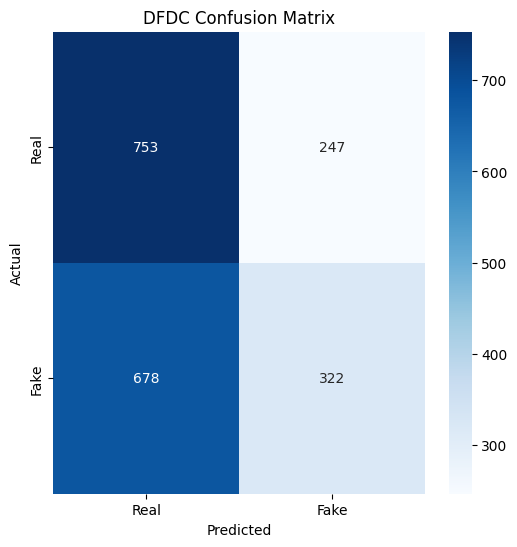

In [94]:
import seaborn as sns

cm=confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(6,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Real","Fake"],
    yticklabels=["Real","Fake"]
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("DFDC Confusion Matrix")

plt.show()

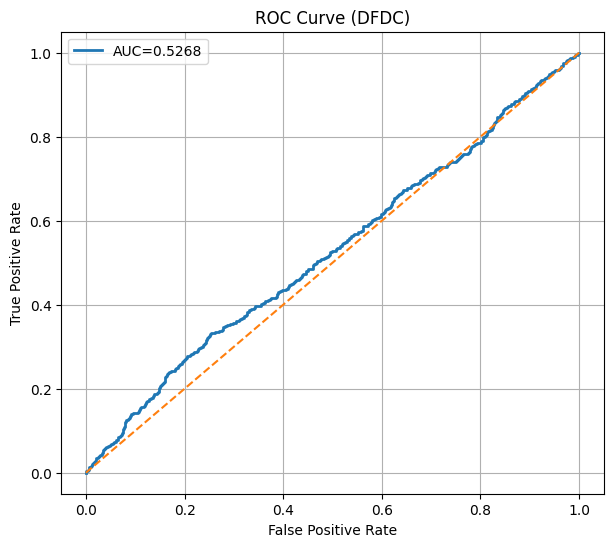

In [95]:
fpr,tpr,_=roc_curve(
    all_labels,
    all_probs
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC={auc:.4f}",
    linewidth=2
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve (DFDC)")

plt.legend()

plt.grid(True)

plt.show()

In [32]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if file.endswith(".pth"):
            print(os.path.join(root, file))

/kaggle/input/datasets/varshavp13/video-model/best_video_model.pth


In [34]:
import os
import cv2
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader

from tqdm import tqdm

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

In [44]:
# ==========================================
# Domain Shift Functions
# ==========================================

def apply_jpeg(frame, quality):

    _, enc = cv2.imencode(
        ".jpg",
        frame,
        [int(cv2.IMWRITE_JPEG_QUALITY), quality]
    )

    return cv2.imdecode(
        enc,
        cv2.IMREAD_COLOR
    )


def apply_blur(frame, k):

    if k <= 1:
        return frame

    return cv2.GaussianBlur(
        frame,
        (k,k),
        0
    )


def apply_downscale(frame, factor):

    if factor <= 1:
        return frame

    h,w = frame.shape[:2]

    small = cv2.resize(
        frame,
        (w//factor,h//factor)
    )

    return cv2.resize(
        small,
        (w,h)
    )


def apply_brightness(frame, delta):

    img = frame.astype(np.int32)

    img = img + delta

    img = np.clip(
        img,
        0,
        255
    )

    return img.astype(np.uint8)

print("Functions Ready")

Functions Ready


In [45]:
class DegradedDFDCDataset(Dataset):

    def __init__(
        self,
        dataframe,
        degrade_fn=None
    ):

        self.df = dataframe.reset_index(drop=True)

        self.degrade_fn = degrade_fn

        self.mean = torch.tensor(
            [0.485,0.456,0.406]
        ).view(1,3,1,1)

        self.std = torch.tensor(
            [0.229,0.224,0.225]
        ).view(1,3,1,1)

    def __len__(self):

        return len(self.df)

    def __getitem__(self,idx):

        row = self.df.iloc[idx]

        video_path = os.path.join(
            DFDC_ROOT,
            row.video
        )

        frames = extract_frames(video_path)

        if self.degrade_fn is not None:

            frames = np.array([
                self.degrade_fn(f)
                for f in frames
            ])

        frames = torch.tensor(
            frames,
            dtype=torch.float32
        )

        frames = frames.permute(
            0,3,1,2
        )

        frames /= 255.

        frames = (
            frames-self.mean
        )/self.std

        label = torch.tensor(
            row.label,
            dtype=torch.float32
        )

        return frames,label

print("Dataset Ready")

Dataset Ready


In [46]:
import cv2
import numpy as np

NUM_FRAMES = 20
IMG_SIZE = 224

def extract_frames(video_path,
                   num_frames=NUM_FRAMES,
                   img_size=IMG_SIZE):

    cap = cv2.VideoCapture(video_path)

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        return np.zeros(
            (num_frames, img_size, img_size, 3),
            dtype=np.uint8
        )

    indices = np.linspace(
        0,
        total_frames - 1,
        num_frames,
        dtype=int
    )

    frames = []

    for idx in indices:

        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)

        success, frame = cap.read()

        if not success:
            frame = np.zeros(
                (img_size, img_size, 3),
                dtype=np.uint8
            )

        else:
            frame = cv2.cvtColor(
                frame,
                cv2.COLOR_BGR2RGB
            )

            frame = cv2.resize(
                frame,
                (img_size, img_size)
            )

        frames.append(frame)

    cap.release()

    return np.array(frames, dtype=np.uint8)

print("✅ extract_frames() Ready")

✅ extract_frames() Ready


In [48]:
# ==========================================
# CELL 5 (FAST VERSION)
# Evaluate on 200 videos only
# ==========================================

# 100 REAL + 100 FAKE

real_df = metadata_df[
    metadata_df.label == 0
].sample(
    n=100,
    random_state=42
)

fake_df = metadata_df[
    metadata_df.label == 1
].sample(
    n=100,
    random_state=42
)

metadata_small = pd.concat(
    [real_df, fake_df]
).sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("Videos:", len(metadata_small))

clean_dataset = DegradedDFDCDataset(
    metadata_small,
    degrade_fn=None
)

clean_loader = DataLoader(
    clean_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0
)

clean_results = evaluate_degraded(
    model,
    clean_loader,
    device
)

print("\nClean Results")
print(clean_results)

Videos: 200


Evaluating: 100%|██████████| 25/25 [24:29<00:00, 58.77s/it]


Clean Results
{'Accuracy': 0.5, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0, 'AUC': np.float64(0.5597), 'MCC': 0.0}


In [55]:
jpeg_dataset = DegradedDFDCDataset(
    metadata_small,
    degrade_fn=lambda f: apply_jpeg(f,30)
)

jpeg_loader = DataLoader(
    jpeg_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0
)

jpeg_results = evaluate_degraded(
    model,
    jpeg_loader,
    device
)

print(jpeg_results)

Evaluating: 100%|██████████| 3/3 [02:31<00:00, 50.34s/it]

{'Accuracy': 0.5, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0, 'AUC': np.float64(0.77), 'MCC': 0.0}


In [56]:
blur_dataset = DegradedDFDCDataset(
    metadata_small,
    degrade_fn=lambda f: apply_blur(f,5)
)

blur_loader = DataLoader(
    blur_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0
)

blur_results = evaluate_degraded(
    model,
    blur_loader,
    device
)

print(blur_results)

Evaluating: 100%|██████████| 3/3 [02:29<00:00, 49.83s/it]

{'Accuracy': 0.5, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0, 'AUC': np.float64(0.77), 'MCC': 0.0}


In [57]:
down_dataset = DegradedDFDCDataset(
    metadata_small,
    degrade_fn=lambda f: apply_downscale(f,2)
)

down_loader = DataLoader(
    down_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0
)

down_results = evaluate_degraded(
    model,
    down_loader,
    device
)

print(down_results)

Evaluating: 100%|██████████| 3/3 [02:29<00:00, 49.90s/it]

{'Accuracy': 0.5, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0, 'AUC': np.float64(0.755), 'MCC': 0.0}


In [58]:
bright_dataset = DegradedDFDCDataset(
    metadata_small,
    degrade_fn=lambda f: apply_brightness(f,-25)
)

bright_loader = DataLoader(
    bright_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0
)

bright_results = evaluate_degraded(
    model,
    bright_loader,
    device
)

print(bright_results)

Evaluating: 100%|██████████| 3/3 [02:29<00:00, 49.89s/it]

{'Accuracy': 0.5, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0, 'AUC': np.float64(0.765), 'MCC': 0.0}


In [59]:
import pandas as pd

comparison = pd.DataFrame({

    "Condition":[
        "Original",
        "JPEG (Q30)",
        "Blur (5x5)",
        "Downscale (2x)",
        "Brightness (-25)"
    ],

    "Accuracy":[
        clean_results["Accuracy"],
        jpeg_results["Accuracy"],
        blur_results["Accuracy"],
        down_results["Accuracy"],
        bright_results["Accuracy"]
    ],

    "AUC":[
        clean_results["AUC"],
        jpeg_results["AUC"],
        blur_results["AUC"],
        down_results["AUC"],
        bright_results["AUC"]
    ]

})

comparison

,Condition,Accuracy,AUC
0,Original,0.5,0.5597
1,JPEG (Q30),0.5,0.7700
2,Blur (5x5),0.5,0.7700
3,Downscale (2x),0.5,0.7550
4,Brightness (-25),0.5,0.7650


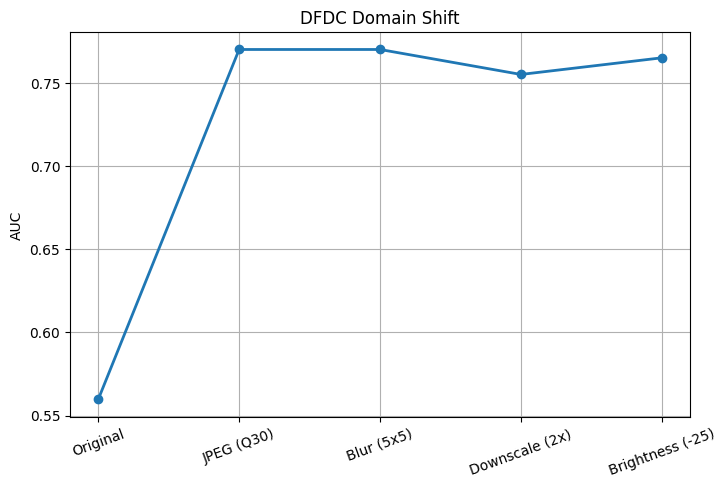

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    comparison["Condition"],
    comparison["AUC"],
    marker="o",
    linewidth=2
)

plt.xticks(rotation=20)
plt.ylabel("AUC")
plt.title("DFDC Domain Shift")

plt.grid(True)

plt.show()

In [61]:
# ==========================================
# 3.6.3 Test-Time Augmentation
# ==========================================

def evaluate_tta(model, dataloader, device):

    model.eval()

    all_labels=[]
    all_probs=[]
    all_preds=[]

    with torch.no_grad():

        for frames,labels in tqdm(
            dataloader,
            desc="TTA Evaluation"
        ):

            frames=frames.to(device)
            labels=labels.to(device)

            # Original prediction
            p1=torch.sigmoid(model(frames))

            # Horizontal Flip
            flip=torch.flip(
                frames,
                dims=[4]
            )

            p2=torch.sigmoid(model(flip))

            # Average prediction
            probs=(p1+p2)/2

            preds=(probs>=0.5).float()

            all_probs.extend(
                probs.cpu().numpy()
            )

            all_preds.extend(
                preds.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

    acc=accuracy_score(all_labels,all_preds)
    auc=roc_auc_score(all_labels,all_probs)

    return acc,auc

In [62]:
tta_acc,tta_auc = evaluate_tta(
    model,
    clean_loader,
    device
)

print("TTA Accuracy :",tta_acc)
print("TTA AUC      :",tta_auc)

TTA Evaluation: 100%|██████████| 25/25 [24:38<00:00, 59.12s/it]

TTA Accuracy : 0.5
TTA AUC      : 0.5397000000000001


In [63]:
import pandas as pd

robustness=pd.DataFrame({

    "Method":[
        "Baseline",
        "Test-Time Augmentation"
    ],

    "Accuracy":[
        clean_results["Accuracy"],
        tta_acc
    ],

    "AUC":[
        clean_results["AUC"],
        tta_auc
    ]

})

robustness

,Method,Accuracy,AUC
0,Baseline,0.5,0.5597
1,Test-Time Augmentation,0.5,0.5397


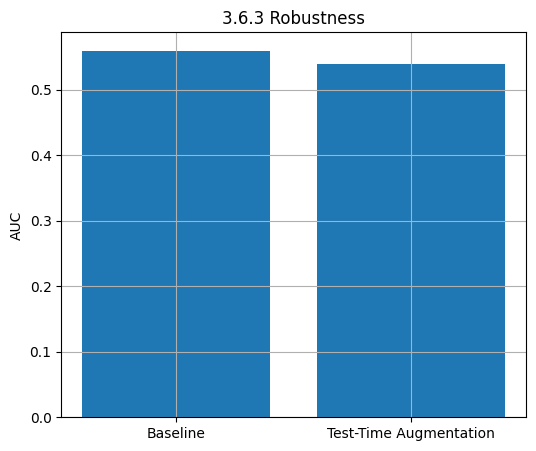

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.bar(
    robustness["Method"],
    robustness["AUC"]
)

plt.ylabel("AUC")

plt.title("3.6.3 Robustness")

plt.grid(True)

plt.show()

In [65]:
robustness.to_csv(
    "/kaggle/working/robustness_results.csv",
    index=False
)

print("Saved Successfully")

Saved Successfully
